In [4]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [5]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"

fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"
czi_name = "CB5-01_S1.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [6]:
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel)

In [7]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

In [8]:
def select_roi(img):
    roi, _ = get_roi_from_result(
    result,
    result['rotate_fn'](img) ,
    region= "full",
    pad_left_um=-1500.0,   # expand chip box leftward (µm)
    pad_right_um=-3000.0,  # expand chip box rightward (µm)
    pad_top_um=1300.0,    # pad above & below main channel centre (symmetric)
    pad_bottom_um= 1300
)
    return roi

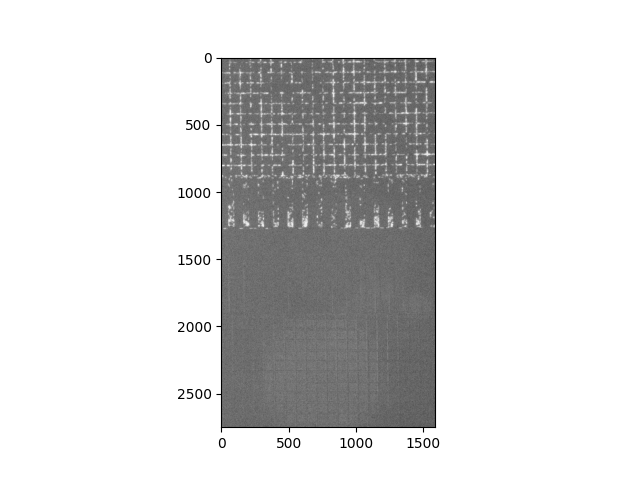

In [9]:

stretch_min = 10
stretch_max = 99.5
channel = 1
time = 0
img, img_disp = get_frame(czi,time,channel,gamma=0.45,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")

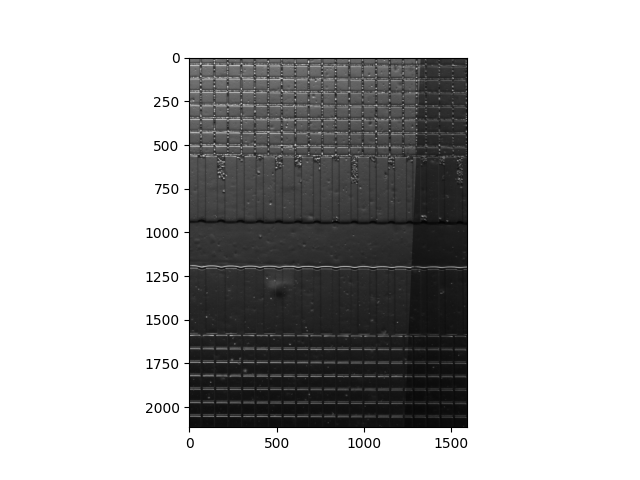

In [33]:

stretch_min = 1
stretch_max = 99.5
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel,gamma=1,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")


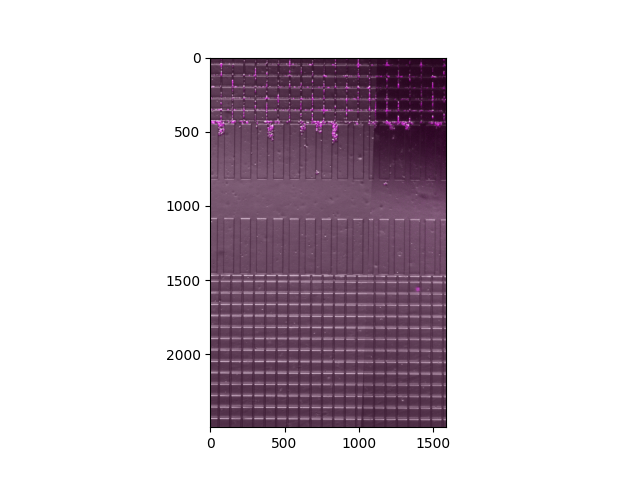

In [95]:
stretch_min = 93
stretch_max = 99.5
_, ch_magenta = get_frame(czi, time, 1,gamma=1,    stretch_min = stretch_min, stretch_max = stretch_max)
_, ch_gray    = get_frame(czi, time, 2, gamma=1)

ch_magenta = norm(select_roi(ch_magenta))
ch_gray    = norm(select_roi(ch_gray))

rgb_magenta = mcherry(ch_magenta)[..., :3]
rgb_gray    = gray_cmap(ch_gray)[..., :3]
merged      = np.clip(rgb_magenta + rgb_gray, 0, 1)
fig,ax = plt.subplots()
ax.imshow(merged)

rolling ball background subtraction done


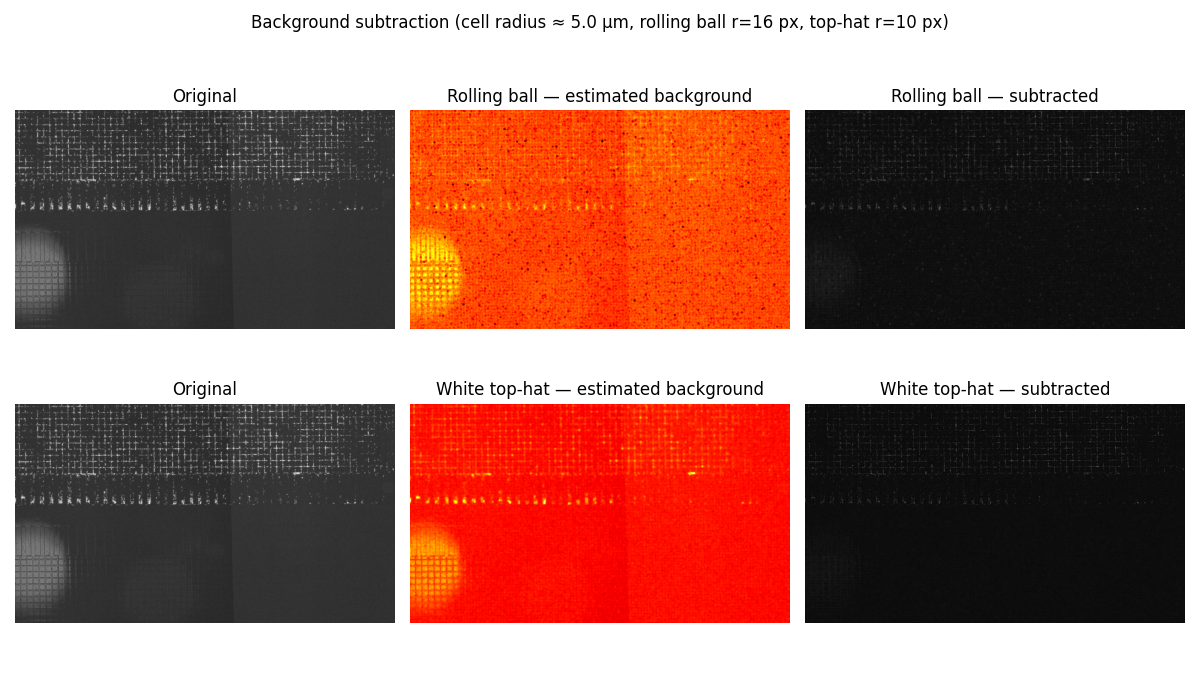

Rolling ball  — background range: 37.8 – 105.1
Top-hat       — result range:     0.0 – 264.5
img updated with rolling-ball background subtraction


In [7]:

from skimage import exposure
from skimage.restoration import rolling_ball
from skimage.morphology import white_tophat, disk

# ── Background subtraction experiment ────────────────────────────────────────
# Load the same channel/frame used below for blob detection
stretch_min = 10
stretch_max = 99.5
channel = 1
time = 0
img, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=stretch_min, stretch_max=stretch_max)
img = select_roi(img.astype(float))
img_disp = select_roi(img_disp)

# ── Method 1: Rolling ball background subtraction ────────────────────────────
# radius should be larger than the largest object of interest (cells ~5 µm)
cell_radius_um = 5.0
radius_px = int(np.round(cell_radius_um * 3 / pixel_size["X"]))  # 3× cell radius
background_rb = rolling_ball(img, radius=radius_px)
img_rb = img - background_rb
img_rb = np.clip(img_rb, 0, None)  # remove negative artefacts
print("rolling ball background subtraction done")
# ── Method 2: White top-hat (morphological) ──────────────────────────────────
# structuring element slightly larger than cells
selem_radius_px = 10
selem = disk(selem_radius_px)
img_tophat = white_tophat(img, selem)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax_row, (img_proc, bg, label) in zip(axes, [
    (img_rb,     background_rb,             "Rolling ball"),
    (img_tophat, img - img_tophat,          "White top-hat"),
]):
    # Normalise each for display
    disp_bg   = exposure.rescale_intensity(bg,       out_range=(0, 1))
    disp_proc = exposure.rescale_intensity(img_proc, out_range=(0, 1))

    ax_row[0].imshow(img_disp, cmap="gray")
    ax_row[0].set_title("Original")
    ax_row[0].axis("off")

    ax_row[1].imshow(disp_bg, cmap="hot")
    ax_row[1].set_title(f"{label} — estimated background")
    ax_row[1].axis("off")

    ax_row[2].imshow(disp_proc, cmap="gray")
    ax_row[2].set_title(f"{label} — subtracted")
    ax_row[2].axis("off")

plt.suptitle(f"Background subtraction (cell radius ≈ {cell_radius_um} µm, "
             f"rolling ball r={radius_px} px, top-hat r={selem_radius_px} px)")
plt.tight_layout()
plt.show()

print(f"Rolling ball  — background range: {background_rb.min():.1f} – {background_rb.max():.1f}")
print(f"Top-hat       — result range:     {img_tophat.min():.1f} – {img_tophat.max():.1f}")

# ── Replace img with background-subtracted version for the cells below ────────
# Comment/uncomment the method you prefer:
img = img_rb        # rolling ball
# img = img_tophat  # white top-hat
print("img updated with rolling-ball background subtraction")


Gaussian BG sigma: 50.0 µm = 52.9 px


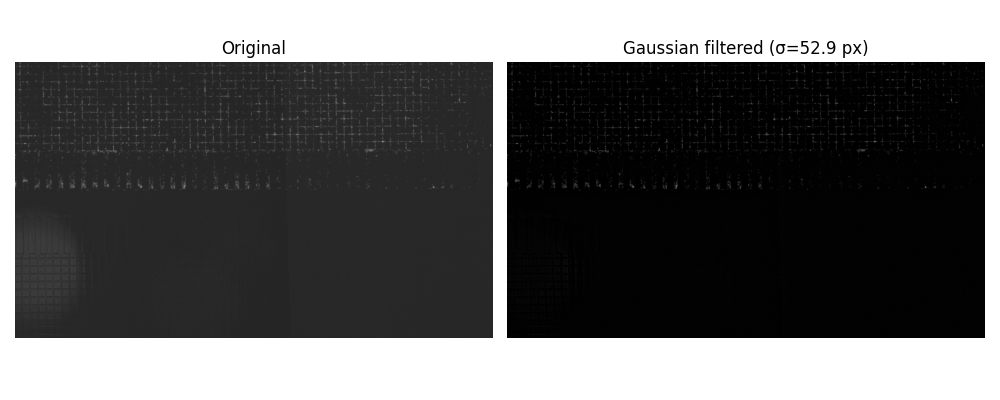

In [18]:
from scipy.ndimage import gaussian_filter

# ── Method 3: Gaussian background subtraction ─────────────────────────────────
# sigma >> cell size so background is smooth and cells are preserved
# Runtime: O(N log N) via FFT — independent of sigma
# Runtime: O(N log N) via FFT — independent of sigma
bg_sigma_um  = 50.0   # much larger than cell (~5 µm) → safe range: 10–50 µm
bg_sigma_px  = bg_sigma_um / pixel_size["X"]

background_gauss = gaussian_filter(img, sigma=bg_sigma_px)
img_gauss        = np.clip(img - background_gauss, 0, None)

print(f"Gaussian BG sigma: {bg_sigma_um} µm = {bg_sigma_px:.1f} px")
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(img_gauss, cmap="gray")
ax[1].set_title(f"Gaussian filtered (σ={bg_sigma_px:.1f} px)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Channel 1: 2714 cell(s) detected


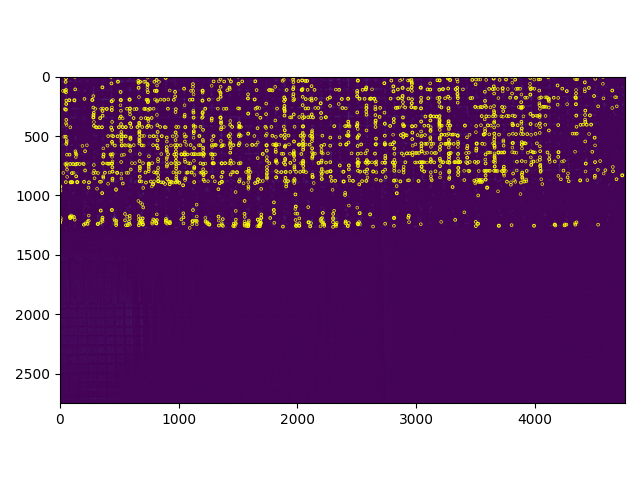

In [19]:
from chipanalysis.functions.region_fluorescence import count_cells
from skimage.feature import blob_doh, blob_log

px_um = pixel_size["X"]

stretch_min = 10
stretch_max = 99.5
channel = 1
time = 0
img, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=stretch_min, stretch_max=stretch_max)
img = select_roi(img.astype(float))
img_disp = select_roi(img_disp)

# Count cells using calibrated function
n_cells = count_cells(img, channel, px_um=px_um)
print(f"Channel {channel}: {n_cells} cell(s) detected")

# For visualization, re-run blob detection with pixel-size-calibrated parameters
from skimage import exposure
p_low  = np.percentile(img_gauss, 0)      # dark background reference
p_high = np.percentile(img_gauss, 100)   # bright signal reference
img_norm = exposure.rescale_intensity(img_gauss, in_range=(p_low, p_high), out_range=(0, 1))
# img_norm = (img_norm - img_norm.mean()) / (img_norm.std() + 1e-8)

# Use calibrated parameters based on channel and pixel size
# Channel 0: ~1-2 µm cells → radius ~0.75 µm
cell_radius_um = 5
sigma_px = (cell_radius_um / px_um) / (2 ** 0.5)
min_sigma = max(1.0, sigma_px * 0.6)
max_sigma = max(2.0, sigma_px * 1.4)

blobs_doh = blob_log(img_norm, min_sigma=min_sigma, max_sigma=max_sigma, num_sigma=10, threshold=0.08)

blobs_list = [blobs_doh]
colors = ['yellow',]
titles = ['Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)
fig, ax = plt.subplots()

ax.imshow(img_gauss)
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color="yellow", linewidth=2, fill=False)
    ax.add_patch(c)

plt.tight_layout()
plt.show()


Channel 1: 1365 cell(s) detected


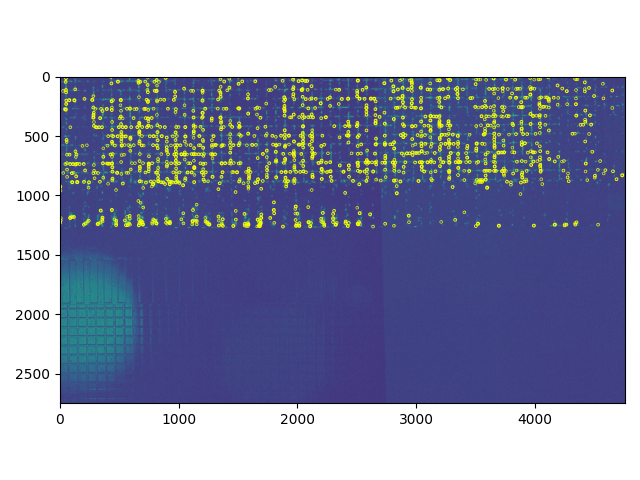

In [ ]:
from chipanalysis.functions.region_fluorescence import count_cells
from skimage.feature import blob_doh, blob_log

px_um = pixel_size["X"]

stretch_min = 10
stretch_max = 99.5
channel = 1
time = 0
img, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=stretch_min, stretch_max=stretch_max)
img = select_roi(img.astype(float))
img_disp = select_roi(img_disp)

# Count cells using calibrated function
n_cells = count_cells(img, channel, px_um=px_um)
print(f"Channel {channel}: {n_cells} cell(s) detected")

# For visualization, re-run blob detection with pixel-size-calibrated parameters
from skimage import exposure
p_low  = np.percentile(img, 0)      # dark background reference
p_high = np.percentile(img, 100)   # bright signal reference
img_norm = exposure.rescale_intensity(img, in_range=(p_low, p_high), out_range=(0, 1))
# img_norm = (img_norm - img_norm.mean()) / (img_norm.std() + 1e-8)

# Use calibrated parameters based on channel and pixel size
# Channel 0: ~1-2 µm cells → radius ~0.75 µm
cell_radius_um = 5
sigma_px = (cell_radius_um / px_um) / (2 ** 0.5)
min_sigma = max(1.0, sigma_px * 0.6)
max_sigma = max(2.0, sigma_px * 1.4)

blobs_doh = blob_log(img_norm, min_sigma=min_sigma, max_sigma=max_sigma, num_sigma=10, threshold=0.08)

blobs_list = [blobs_doh]
colors = ['yellow',]
titles = ['Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)
fig, ax = plt.subplots()

ax.imshow(img_disp)
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color="yellow", linewidth=2, fill=False)
    ax.add_patch(c)

plt.tight_layout()
plt.show()



Channel 0: 4510 cell(s) detected


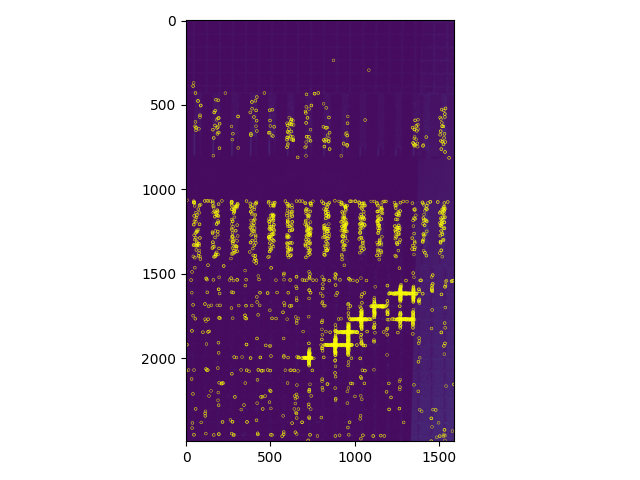

In [30]:
from chipanalysis.functions.region_fluorescence import count_cells
from skimage.feature import blob_doh

px_um = pixel_size["X"]

stretch_min = 10
stretch_max = 99.5
channel = 0
time = 0
img, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=stretch_min, stretch_max=stretch_max)
img = select_roi(img.astype(float))
img_disp = select_roi(img_disp)

# Count cells using calibrated function
n_cells = count_cells(img, channel, px_um=px_um)
print(f"Channel {channel}: {n_cells} cell(s) detected")

# For visualization, re-run blob detection with pixel-size-calibrated parameters
from skimage import exposure
img_norm = exposure.rescale_intensity(img, in_range='image', out_range=(0, 1))
# img_norm = (img_norm - img_norm.mean()) / (img_norm.std() + 1e-8)

# Use calibrated parameters based on channel and pixel size
# Channel 0: ~1-2 µm cells → radius ~0.75 µm
cell_radius_um = 1.5
sigma_px = (cell_radius_um / px_um) / (2 ** 0.5)
min_sigma = max(1.0, sigma_px * 0.6)
max_sigma = max(2.0, sigma_px * 1.4)

blobs_doh = blob_log(img_norm, min_sigma=min_sigma, max_sigma=max_sigma, num_sigma=10, threshold=0.03)

blobs_list = [blobs_doh]
colors = ['yellow',]
titles = ['Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)
fig, ax = plt.subplots()

ax.imshow(img_disp)
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color="yellow", linewidth=2, fill=False)
    ax.add_patch(c)

plt.tight_layout()
plt.show()


In [31]:
egwe

NameError: name 'egwe' is not defined

In [ ]:
stretch_min = 93
stretch_max = 99.5
channel = 1
img, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=stretch_min, stretch_max=stretch_max)
img = select_roi(img.astype(float))
img_disp = select_roi(img_disp)

from skimage.measure import block_reduce

# Test robustness: compare counts at different resolutions
print(f"\n=== Robustness Test (Binning) ===")
print(f"Original image shape: {img.shape}")
print(f"Pixel size: {px_um:.4f} µm")

# Test different bin sizes
bin_factors = [1, 2, 4]
results = []

for bin_factor in bin_factors:
    if bin_factor == 1:
        img_binned = img
        img_disp_binned = img_disp
        px_um_binned = px_um
    else:
        # Block reduce averages bin_factor × bin_factor pixels
        img_binned = block_reduce(img, block_size=(bin_factor, bin_factor), func=np.mean)
        img_disp_binned = block_reduce(img_disp, block_size=(bin_factor, bin_factor), func=np.mean)
        px_um_binned = px_um * bin_factor
    
    n_cells_binned = count_cells(img_binned, channel, px_um=px_um_binned)
    results.append({
        "bin_factor": bin_factor,
        "shape": img_binned.shape,
        "px_um": px_um_binned,
        "n_cells": n_cells_binned,
        "img": img_binned,
        "img_disp": img_disp_binned,
    })
    print(f"  Bin {bin_factor}×: shape={img_binned.shape}, px={px_um_binned:.4f} µm, count={n_cells_binned}")

# Compare counts
orig_count = results[0]["n_cells"]
print(f"\nOriginal count: {orig_count}")
for res in results[1:]:
    diff = res["n_cells"] - orig_count
    pct = 100 * diff / orig_count if orig_count > 0 else 0
    print(f"  Bin {res['bin_factor']}× diff: {diff:+d} ({pct:+.1f}%)")




=== Robustness Test (Binning) ===
Original image shape: (2804, 2102)
Pixel size: 0.7134 µm
  Bin 1×: shape=(2804, 2102), px=0.7134 µm, count=373
  Bin 2×: shape=(1402, 1051), px=1.4267 µm, count=369
  Bin 4×: shape=(701, 526), px=2.8534 µm, count=194

Original count: 373
  Bin 2× diff: -4 (-1.1%)
  Bin 4× diff: -179 (-48.0%)


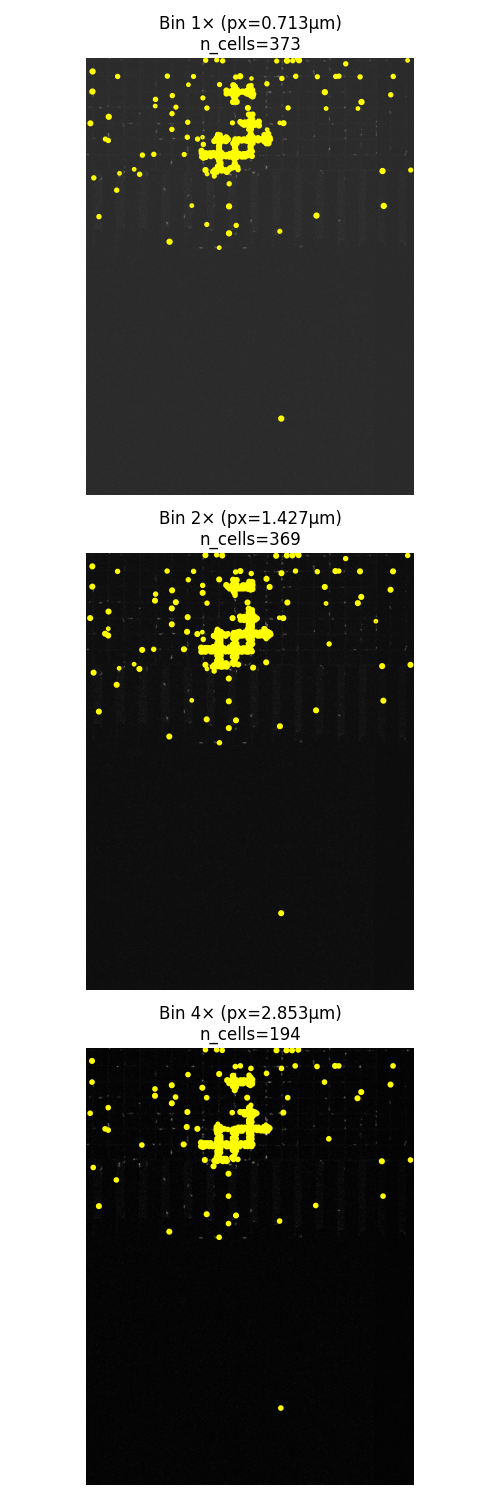

In [ ]:
# Visualize: overlay detections on each binned image
fig, axes = plt.subplots(len(bin_factors), 1, figsize=(5,len(bin_factors)* 5))
if len(bin_factors) == 1:
    axes = [axes]

for ax, res in zip(axes, results):
    bin_factor = res["bin_factor"]
    img_binned = res["img"]
    img_disp_binned = res["img_disp"]
    px_um_binned = res["px_um"]
    
    # Re-detect at this resolution for visualization
    img_norm = exposure.rescale_intensity(img_binned, in_range='image', out_range=(0, 1))
    img_norm = (img_norm - img_norm.mean()) / (img_norm.std() + 1e-8)
    
    cell_radius_um = 8.0
    sigma_px = (cell_radius_um / px_um_binned) / (2 ** 0.5)
    min_sigma = max(1.0, sigma_px * 0.6)
    max_sigma = max(2.0, sigma_px * 1.4)
    blobs_vis = blob_doh(img_norm, min_sigma=min_sigma, max_sigma=max_sigma, num_sigma=10, threshold=0.1)
    
    ax.imshow(img_disp_binned, cmap='gray')
    for blob in blobs_vis:
        y, x, r = blob
        circ = plt.Circle((x, y), r, color='yellow', linewidth=2, fill=False)
        ax.add_patch(circ)
    
    ax.set_title(f"Bin {bin_factor}× (px={px_um_binned:.3f}µm)\nn_cells={res['n_cells']}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Noise gate: 38/81 tiles replaced by global floor (gate=0.4521, global_thresh=0.2057)
Channel 1 — local Triangle threshold (gated)
  Target tile size    : 300.0 µm
  Actual tile grid    : 9×9  (288.9 µm per side)
  Threshold factor    : 0.9
  Threshold range     : 0.1874 – 0.2223
  Total area          : 173,150.4 µm²
  ROI area            : 3,900,068.4 µm²
  Coverage            : 4.44 %


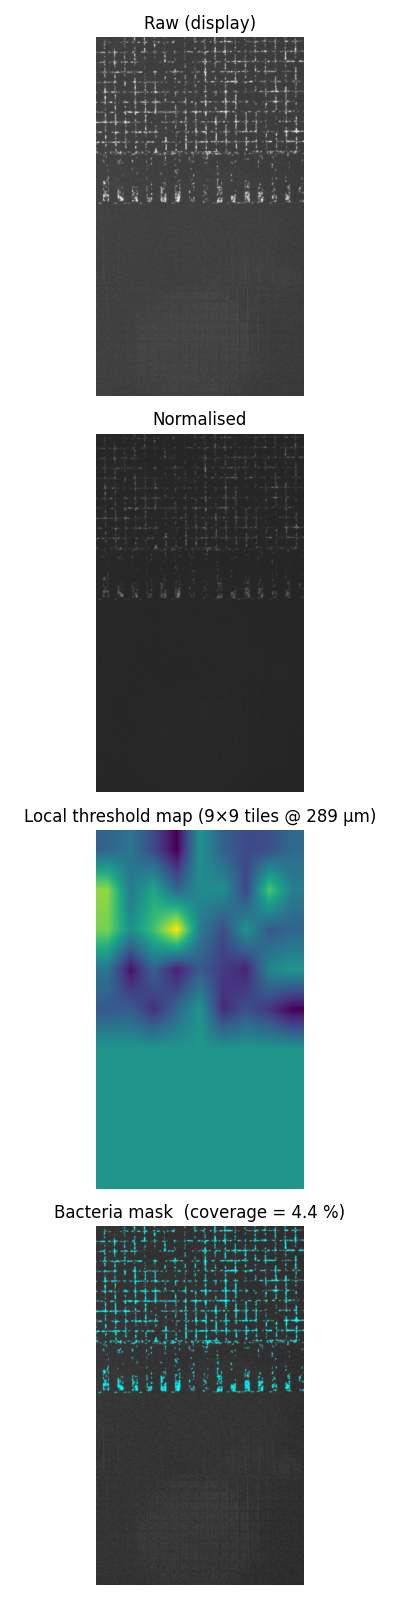

In [12]:

from skimage import exposure, transform
from skimage.filters import threshold_triangle
from skimage.morphology import remove_small_objects, remove_small_holes
import matplotlib.pyplot as plt
import numpy as np

# ── Parameters ───────────────────────────────────────────────────────────────
channel      = 1          # bacteria fluorescence channel
time         = 0

TARGET_TILE_SIZE_UM = 300.0  # target tile size in µm (controls locality)
THRESH_FACTOR       = 0.9   # relaxation factor: 1.0 = strict Triangle, <1 = more permissive

# Noise gate: minimum signal percentile a tile must exceed to use its local threshold.
# If the tile's max intensity is below this global percentile, the tile is considered
# pure background and gets the global floor threshold instead.
# Typical range: 90–99 (percentile of the full image).
SIGNAL_GATE_PERCENTILE = 99.9

# Morphological cleanup
MIN_OBJ_UM2  = 10.0
MAX_HOLE_UM2 = 1.0

# ── Load & crop ───────────────────────────────────────────────────────────────
px_um = pixel_size["X"]
img_raw, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=1, stretch_max=99.5)
img_raw  = select_roi(img_raw.astype(float))
img_disp = select_roi(img_disp)

img_norm = exposure.rescale_intensity(img_raw, out_range=(0.0, 1.0))
H, W = img_norm.shape

# ── Compute global threshold (used as floor for background tiles) ─────────────
global_thresh = threshold_triangle(img_norm) * THRESH_FACTOR
signal_gate   = np.percentile(img_norm, SIGNAL_GATE_PERCENTILE)

# ── Calculate tile grid ───────────────────────────────────────────────────────
img_height_um = H * px_um
img_width_um  = W * px_um
n_tiles_h = max(1, int(np.ceil(img_height_um / TARGET_TILE_SIZE_UM)))
n_tiles_w = max(1, int(np.ceil(img_width_um  / TARGET_TILE_SIZE_UM)))
TILE_GRID = max(n_tiles_h, n_tiles_w)

actual_tile_size_um = img_height_um / TILE_GRID

# ── Build per-tile threshold map ──────────────────────────────────────────────
thresh_map_coarse = np.zeros((TILE_GRID, TILE_GRID), dtype=float)
n_gated = 0

for row in range(TILE_GRID):
    for col in range(TILE_GRID):
        r0, r1 = int(row * H / TILE_GRID), int((row + 1) * H / TILE_GRID)
        c0, c1 = int(col * W / TILE_GRID), int((col + 1) * W / TILE_GRID)
        tile = img_norm[r0:r1, c0:c1]

        local_thresh = threshold_triangle(tile) * THRESH_FACTOR

        # If the tile's max doesn't reach the signal gate, it's pure background:
        # use the global floor so noise doesn't get segmented.
        if tile.max() < signal_gate:
            thresh_map_coarse[row, col] = global_thresh
            n_gated += 1
        else:
            # Allow the local threshold to go below the global only when there's
            # genuine signal in the tile.
            thresh_map_coarse[row, col] = local_thresh

print(f"Noise gate: {n_gated}/{TILE_GRID**2} tiles replaced by global floor "
      f"(gate={signal_gate:.4f}, global_thresh={global_thresh:.4f})")

# ── Bilinear interpolation back to full image size ────────────────────────────
thresh_map = transform.resize(
    thresh_map_coarse,
    (H, W),
    order=1,
    mode="edge",
    anti_aliasing=False,
)

# ── Apply local threshold ─────────────────────────────────────────────────────
binary = img_norm > thresh_map

# ── Morphological clean-up ────────────────────────────────────────────────────
min_obj_px  = max(1, int(np.round(MIN_OBJ_UM2  / px_um ** 2)))
max_hole_px = max(1, int(np.round(MAX_HOLE_UM2 / px_um ** 2)))
binary = remove_small_objects(binary, max_size=min_obj_px)
binary = remove_small_holes(binary,   max_size=max_hole_px)

# ── Area measurement ──────────────────────────────────────────────────────────
bac_area_um2  = binary.sum() * px_um ** 2
roi_area_um2  = binary.size  * px_um ** 2
bac_fraction  = binary.mean()

print(f"Channel {channel} — local Triangle threshold (gated)")
print(f"  Target tile size    : {TARGET_TILE_SIZE_UM:.1f} µm")
print(f"  Actual tile grid    : {TILE_GRID}×{TILE_GRID}  ({actual_tile_size_um:.1f} µm per side)")
print(f"  Threshold factor    : {THRESH_FACTOR}")
print(f"  Threshold range     : {thresh_map_coarse.min():.4f} – {thresh_map_coarse.max():.4f}")
print(f"  Total area          : {bac_area_um2:,.1f} µm²")
print(f"  ROI area            : {roi_area_um2:,.1f} µm²")
print(f"  Coverage            : {bac_fraction * 100:.2f} %")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(4, 16), sharex=True, sharey=True)

axes[0].imshow(img_disp, cmap="gray")
axes[0].set_title("Raw (display)")

axes[1].imshow(img_norm, cmap="gray")
axes[1].set_title("Normalised")

axes[2].imshow(thresh_map, cmap="viridis")
axes[2].set_title(f"Local threshold map ({TILE_GRID}×{TILE_GRID} tiles @ {actual_tile_size_um:.0f} µm)")

overlay = np.stack([img_disp, img_disp, img_disp], axis=-1).astype(float)
overlay[binary, 0] = 0.0
overlay[binary, 1] = overlay[binary, 1] * 0.3 + 0.7
overlay[binary, 2] = overlay[binary, 2] * 0.3 + 0.7
axes[3].imshow(np.clip(overlay, 0, 1))
axes[3].set_title(f"Bacteria mask  (coverage = {bac_fraction*100:.1f} %)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


Noise gate: 0/49 tiles replaced by global floor (gate=0.0483, global_thresh=0.0391)
Channel 0 — local Triangle threshold (gated)
  Target tile size    : 300.0 µm
  Actual tile grid    : 7×7  (285.7 µm per side)
  Threshold factor    : 0.8
  Threshold range     : 0.0314 – 0.0438
  Total area          : 68,583.9 µm²
  ROI area            : 2,999,323.1 µm²
  Coverage            : 2.29 %


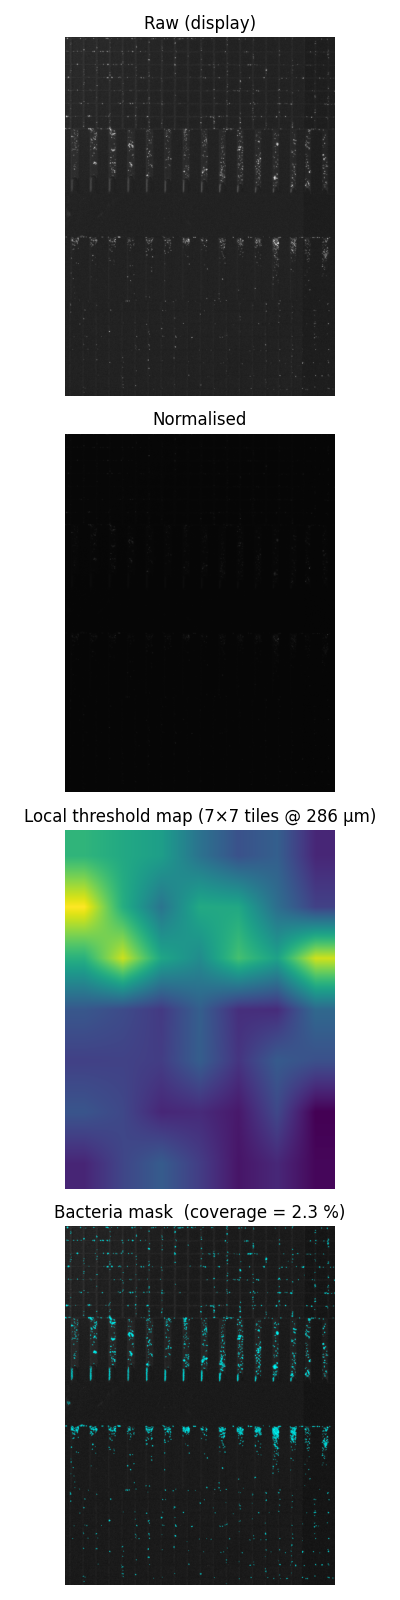

In [ ]:

from skimage import exposure, transform
from skimage.filters import threshold_triangle
from skimage.morphology import remove_small_objects, remove_small_holes
import matplotlib.pyplot as plt
import numpy as np

# ── Parameters ───────────────────────────────────────────────────────────────
channel      = 0          # bacteria fluorescence channel
time         = 0

TARGET_TILE_SIZE_UM = 300.0  # target tile size in µm (controls locality)
THRESH_FACTOR       = 0.8    # relaxation factor: 1.0 = strict Triangle, <1 = more permissive

# Noise gate: minimum signal percentile a tile must exceed to use its local threshold.
# If the tile's max intensity is below this global percentile, the tile is considered
# pure background and gets the global floor threshold instead.
# Typical range: 90–99 (percentile of the full image).
SIGNAL_GATE_PERCENTILE = 99.0

# Morphological cleanup
MIN_OBJ_UM2  = 10.0
MAX_HOLE_UM2 = 1.0

# ── Load & crop ───────────────────────────────────────────────────────────────
px_um = pixel_size["X"]
img_raw, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=1, stretch_max=99.5)
img_raw  = select_roi(img_raw.astype(float))
img_disp = select_roi(img_disp)

img_norm = exposure.rescale_intensity(img_raw, out_range=(0.0, 1.0))
H, W = img_norm.shape

# ── Compute global threshold (used as floor for background tiles) ─────────────
global_thresh = threshold_triangle(img_norm) * THRESH_FACTOR
signal_gate   = np.percentile(img_norm, SIGNAL_GATE_PERCENTILE)

# ── Calculate tile grid ───────────────────────────────────────────────────────
img_height_um = H * px_um
img_width_um  = W * px_um
n_tiles_h = max(1, int(np.ceil(img_height_um / TARGET_TILE_SIZE_UM)))
n_tiles_w = max(1, int(np.ceil(img_width_um  / TARGET_TILE_SIZE_UM)))
TILE_GRID = max(n_tiles_h, n_tiles_w)

actual_tile_size_um = img_height_um / TILE_GRID

# ── Build per-tile threshold map ──────────────────────────────────────────────
thresh_map_coarse = np.zeros((TILE_GRID, TILE_GRID), dtype=float)
n_gated = 0

for row in range(TILE_GRID):
    for col in range(TILE_GRID):
        r0, r1 = int(row * H / TILE_GRID), int((row + 1) * H / TILE_GRID)
        c0, c1 = int(col * W / TILE_GRID), int((col + 1) * W / TILE_GRID)
        tile = img_norm[r0:r1, c0:c1]

        local_thresh = threshold_triangle(tile) * THRESH_FACTOR

        # If the tile's max doesn't reach the signal gate, it's pure background:
        # use the global floor so noise doesn't get segmented.
        if tile.max() < signal_gate:
            thresh_map_coarse[row, col] = global_thresh
            n_gated += 1
        else:
            # Allow the local threshold to go below the global only when there's
            # genuine signal in the tile.
            thresh_map_coarse[row, col] = local_thresh

print(f"Noise gate: {n_gated}/{TILE_GRID**2} tiles replaced by global floor "
      f"(gate={signal_gate:.4f}, global_thresh={global_thresh:.4f})")

# ── Bilinear interpolation back to full image size ────────────────────────────
thresh_map = transform.resize(
    thresh_map_coarse,
    (H, W),
    order=1,
    mode="edge",
    anti_aliasing=False,
)

# ── Apply local threshold ─────────────────────────────────────────────────────
binary = img_norm > thresh_map

# ── Morphological clean-up ────────────────────────────────────────────────────
min_obj_px  = max(1, int(np.round(MIN_OBJ_UM2  / px_um ** 2)))
max_hole_px = max(1, int(np.round(MAX_HOLE_UM2 / px_um ** 2)))
binary = remove_small_objects(binary, max_size=min_obj_px)
binary = remove_small_holes(binary,   max_size=max_hole_px)

# ── Area measurement ──────────────────────────────────────────────────────────
bac_area_um2  = binary.sum() * px_um ** 2
roi_area_um2  = binary.size  * px_um ** 2
bac_fraction  = binary.mean()

print(f"Channel {channel} — local Triangle threshold (gated)")
print(f"  Target tile size    : {TARGET_TILE_SIZE_UM:.1f} µm")
print(f"  Actual tile grid    : {TILE_GRID}×{TILE_GRID}  ({actual_tile_size_um:.1f} µm per side)")
print(f"  Threshold factor    : {THRESH_FACTOR}")
print(f"  Threshold range     : {thresh_map_coarse.min():.4f} – {thresh_map_coarse.max():.4f}")
print(f"  Total area          : {bac_area_um2:,.1f} µm²")
print(f"  ROI area            : {roi_area_um2:,.1f} µm²")
print(f"  Coverage            : {bac_fraction * 100:.2f} %")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(4, 16), sharex=True, sharey=True)

axes[0].imshow(img_disp, cmap="gray")
axes[0].set_title("Raw (display)")

axes[1].imshow(img_norm, cmap="gray")
axes[1].set_title("Normalised")

axes[2].imshow(thresh_map, cmap="viridis")
axes[2].set_title(f"Local threshold map ({TILE_GRID}×{TILE_GRID} tiles @ {actual_tile_size_um:.0f} µm)")

overlay = np.stack([img_disp, img_disp, img_disp], axis=-1).astype(float)
overlay[binary, 0] = 0.0
overlay[binary, 1] = overlay[binary, 1] * 0.3 + 0.7
overlay[binary, 2] = overlay[binary, 2] * 0.3 + 0.7
axes[3].imshow(np.clip(overlay, 0, 1))
axes[3].set_title(f"Bacteria mask  (coverage = {bac_fraction*100:.1f} %)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:

from skimage.measure import block_reduce

# ── Robustness Test: apply local Triangle at different resolutions (binning) ──
# Key: bin img_raw first, then re-normalise each version independently to [0,1].
# Binning img_norm directly would dilute bright bacteria peaks and shift Triangle.
print(f"\n=== Robustness Test: Local Triangle @ Different Resolutions ===")
print(f"Original image shape: {img_raw.shape}")
print(f"Pixel size: {px_um:.4f} µm")
print(f"Target tile size: {TARGET_TILE_SIZE_UM:.1f} µm, grid: {TILE_GRID}×{TILE_GRID}\n")

bin_factors = [1, 2, 4]
results_triangle = []

for bin_factor in bin_factors:
    if bin_factor == 1:
        img_raw_binned  = img_raw
        img_disp_binned = img_disp
        px_um_binned    = px_um
    else:
        img_raw_binned  = block_reduce(img_raw,  block_size=(bin_factor, bin_factor), func=np.mean)
        img_disp_binned = block_reduce(img_disp, block_size=(bin_factor, bin_factor), func=np.mean)
        px_um_binned    = px_um * bin_factor

    H_binned, W_binned = img_raw_binned.shape

    # Re-normalise to [0,1] at this resolution so Triangle sees the full dynamic range
    img_norm_binned = exposure.rescale_intensity(img_raw_binned, out_range=(0.0, 1.0))

    thresh_map_coarse_binned = np.zeros((TILE_GRID, TILE_GRID), dtype=float)
    for row in range(TILE_GRID):
        for col in range(TILE_GRID):
            r0, r1 = int(row * H_binned / TILE_GRID), int((row + 1) * H_binned / TILE_GRID)
            c0, c1 = int(col * W_binned / TILE_GRID), int((col + 1) * W_binned / TILE_GRID)
            tile = img_norm_binned[r0:r1, c0:c1]
            if tile.size > 0:
                thresh_map_coarse_binned[row, col] = threshold_triangle(tile) * THRESH_FACTOR

    thresh_map_binned = transform.resize(
        thresh_map_coarse_binned,
        (H_binned, W_binned),
        order=1,
        mode="edge",
        anti_aliasing=False,
    )

    binary_binned = img_norm_binned > thresh_map_binned

    # Morphological cleanup — areas kept in µm² so they scale correctly
    min_obj_px_binned  = max(1, int(np.round(MIN_OBJ_UM2  / px_um_binned ** 2)))
    max_hole_px_binned = max(1, int(np.round(MAX_HOLE_UM2 / px_um_binned ** 2)))
    binary_binned = remove_small_objects(binary_binned, max_size=min_obj_px_binned)
    binary_binned = remove_small_holes(binary_binned,   max_size=max_hole_px_binned)

    bac_area_binned     = binary_binned.sum() * px_um_binned ** 2
    bac_fraction_binned = binary_binned.mean()

    results_triangle.append({
        "bin_factor":  bin_factor,
        "shape":       img_raw_binned.shape,
        "px_um":       px_um_binned,
        "area":        bac_area_binned,
        "fraction":    bac_fraction_binned,
        "img_disp":    img_disp_binned,
        "img_norm":    img_norm_binned,
        "binary":      binary_binned,
        "thresh_map":  thresh_map_binned,
    })

    print(f"  Bin {bin_factor}×: shape={img_raw_binned.shape}, px={px_um_binned:.4f} µm, "
          f"thresh=[{thresh_map_coarse_binned.min():.4f}–{thresh_map_coarse_binned.max():.4f}], "
          f"area={bac_area_binned:,.0f} µm², coverage={bac_fraction_binned*100:.2f}%")

# Summary comparison
print(f"\nComparison to bin 1×:")
orig_area = results_triangle[0]["area"]
orig_frac = results_triangle[0]["fraction"]
for res in results_triangle[1:]:
    area_pct    = 100 * (res["area"] - orig_area) / orig_area if orig_area > 0 else 0
    frac_diff   = (res["fraction"] - orig_frac) * 100
    print(f"  Bin {res['bin_factor']}×: area Δ={res['area']-orig_area:+,.0f} µm² ({area_pct:+.1f}%), "
          f"coverage Δ={frac_diff:+.2f} pp")



=== Robustness Test: Local Triangle @ Different Resolutions ===
Original image shape: (2804, 2102)
Pixel size: 0.7134 µm
Target tile size: 300.0 µm, grid: 7×7

  Bin 1×: shape=(2804, 2102), px=0.7134 µm, thresh=[0.0314–0.0438], area=68,584 µm², coverage=2.29%
  Bin 2×: shape=(1402, 1051), px=1.4267 µm, thresh=[0.0225–0.0355], area=115,527 µm², coverage=3.85%
  Bin 4×: shape=(701, 526), px=2.8534 µm, thresh=[0.0598–0.0816], area=2,379,947 µm², coverage=79.27%

Comparison to bin 1×:
  Bin 2×: area Δ=+46,943 µm² (+68.4%), coverage Δ=+1.57 pp
  Bin 4×: area Δ=+2,311,363 µm² (+3370.1%), coverage Δ=+76.99 pp


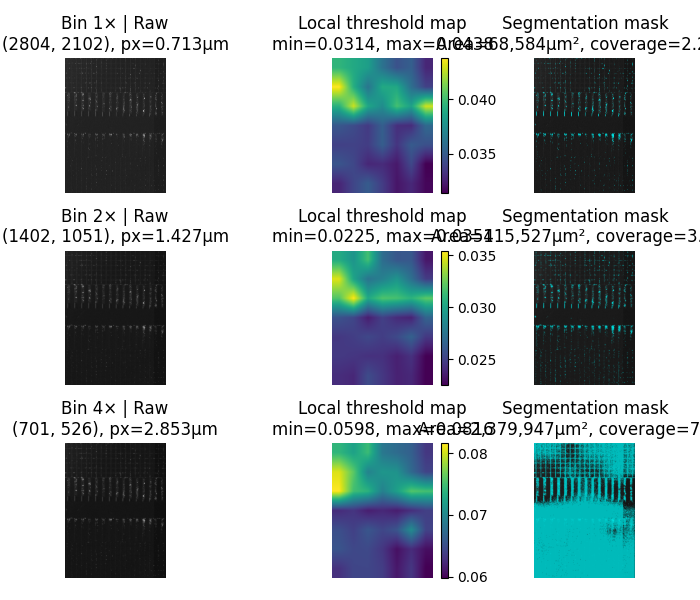

In [ ]:

# Visualize: overlay local Triangle masks at each resolution
fig, axes = plt.subplots(len(bin_factors), 3, figsize=(7, len(bin_factors) * 2), sharex=False, sharey=False)
if len(bin_factors) == 1:
    axes = axes.reshape(1, -1)

for row, res in enumerate(results_triangle):
    bin_factor = res["bin_factor"]
    img_disp_b = res["img_disp"]
    thresh_map_b = res["thresh_map"]
    binary_b = res["binary"]
    
    # Panel 1: raw display
    axes[row, 0].imshow(img_disp_b, cmap="gray")
    axes[row, 0].set_title(f"Bin {bin_factor}× | Raw\n{img_disp_b.shape}, px={res['px_um']:.3f}µm")
    axes[row, 0].axis("off")
    
    # Panel 2: threshold map heatmap
    im = axes[row, 1].imshow(thresh_map_b, cmap="viridis")
    axes[row, 1].set_title(f"Local threshold map\nmin={thresh_map_b.min():.4f}, max={thresh_map_b.max():.4f}")
    axes[row, 1].axis("off")
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
    
    # Panel 3: mask overlay (teal highlight on bacteria)
    overlay_b = np.stack([img_disp_b, img_disp_b, img_disp_b], axis=-1).astype(float)
    overlay_b[binary_b, 0] = 0.0  # red channel → 0
    overlay_b[binary_b, 1] = overlay_b[binary_b, 1] * 0.3 + 0.7  # green → lighter
    overlay_b[binary_b, 2] = overlay_b[binary_b, 2] * 0.3 + 0.7  # blue → lighter
    axes[row, 2].imshow(np.clip(overlay_b, 0, 1))
    axes[row, 2].set_title(f"Segmentation mask\nArea={res['area']:,.0f}µm², coverage={res['fraction']*100:.2f}%")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()


(array([0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 4.00000e+00, 5.00000e+00, 9.00000e+00,
        1.40000e+01, 2.50000e+01, 3.30000e+01, 4.90000e+01, 4.90000e+01,
        9.60000e+01, 1.29000e+02, 2.01000e+02, 4.16000e+02, 9.48000e+02,
        1.71500e+03, 3.17500e+03, 6.31300e+03, 1.18030e+04, 2.05420e+04,
        3.34540e+04, 5.25460e+04, 7.93610e+04, 1.12312e+05, 1.47708e+05,
        1.83998e+05, 2.19201e+05, 2.48026e+05, 2.62

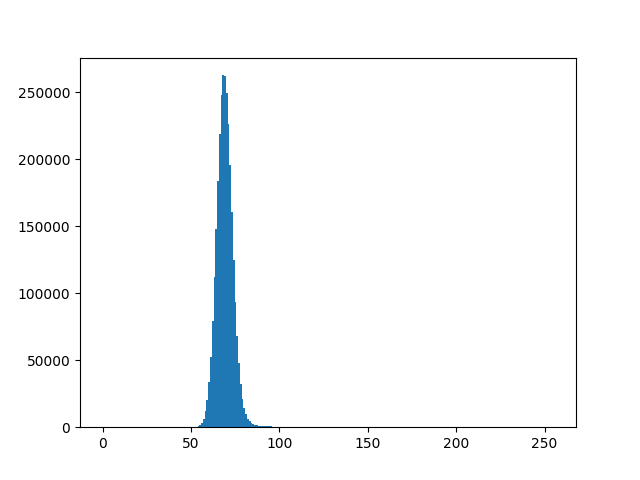

In [ ]:
fig,ax = plt.subplots()
ax.hist(img.flatten(), bins=256, range=(0, 255))